In [1]:
import numpy as np 
import tensorflow as tf
import cv2 as cv
import os
import mediapipe as mp 

In [2]:
from dataLoader import quick_load
# Path to your dataset
dataset_path = r"D:\GP\cleaned_landmarks_100words\cleaned_landmarks_100words"
    
# ============================================================
# METHOD 1: One-line loading (simplest)
# ============================================================
print("\n" + "="*60)
print("METHOD 1: One-line loading")
print("="*60)
cleaned_data, cleaned_labels = quick_load(dataset_path)
print(f"Loaded {len(cleaned_data)} samples")


METHOD 1: One-line loading
📦 Loading metadata from cache: D:\GP\cleaned_landmarks_100words\cleaned_landmarks_100words\.cache\metadata.pkl
✅ Loaded metadata for 2984 files


Loading data: 100%|██████████| 2984/2984 [00:01<00:00, 1894.69it/s]

Loaded 2984 samples


In [27]:

dataset_path = r"D:\GP\before_cleaning_landmarks_100words\before_cleaning_landmarks_100words"
    
# ============================================================
# METHOD 1: One-line loading (simplest)
# ============================================================
print("\n" + "="*60)
print("METHOD 1: One-line loading")
print("="*60)
notcleaned_data, notcleaned_labels, = quick_load(dataset_path)
print(f"Loaded {len(notcleaned_data)} samples")


METHOD 1: One-line loading
📦 Loading metadata from cache: D:\GP\before_cleaning_landmarks_100words\before_cleaning_landmarks_100words\.cache\metadata.pkl
✅ Loaded metadata for 3283 files


Loading data: 100%|██████████| 3283/3283 [00:39<00:00, 82.98it/s] 

Loaded 3283 samples


In [4]:

# Method 3: Using numpy (if cleaned_data is a numpy array with object dtype)
if isinstance(cleaned_data, np.ndarray):
    max_frames = max([seq.shape[0] for seq in cleaned_data])
    print(f"Max frame length: {max_frames}")

Max frame length: 268


In [6]:

# Import the class
from enhancedPreprocessing.preprocessing import HandSwapPreprocessor

# Create preprocessor instance with custom settings
preprocessor = HandSwapPreprocessor(
    confidence_threshold=0.55,  # Higher = fewer false positives
    temporal_window=7,           # Larger = more conservative
    swap_duration_threshold=3,   # Need 3+ consecutive frames
    iou_threshold=0.25,          # Detect hand overlap
    verbose=True                 # Print progress
)

# Or use default settings
# preprocessor = HandSwapPreprocessor()

# Process your data
processed_data, processed_masks, processed_labels, swapped_videos, swap_counts = preprocessor.process_dataset(
    cleaned_data=cleaned_data,
    cleaned_labels=cleaned_labels,
    max_frames=None  # Auto-detect
)

# Access results
print(f"Processed data shape: {processed_data.shape}")
print(f"Processed masks shape: {processed_masks.shape}")
print(f"Videos with swaps: {swapped_videos}")

# Get swapped videos summary
swapped_videos, swap_counts = preprocessor.get_swapped_videos()
preprocessor.print_swap_summary()


 Auto-detected max_frames: 268

 Processing 2984 sequences...
   Target frames: 268
   Confidence threshold: 0.55
   Temporal window: 7


100%|██████████| 2984/2984 [00:49<00:00, 60.23it/s] 



✅ PROCESSING COMPLETE!

✅ NO hand swaps detected in any video!

 Final Statistics:
   Total videos processed: 2984
   Videos with swaps: 0
   Processed data shape: (2984, 268, 438)
   Processed masks shape: (2984, 268)
   Valid frames proportion: 0.150
Processed data shape: (2984, 268, 438)
Processed masks shape: (2984, 268)
Videos with swaps: []

No hand swaps detected


In [5]:
import os
import numpy as np
import cv2
from pathlib import Path

def render_skeleton(data, canvas_size=(480,640), dynamic=True):
    h, w = canvas_size
    img = np.zeros((h, w, 3), dtype=np.uint8)

    # ---- RESHAPE LANDMARKS ----
    pose = data[0:132].reshape(33, 4)
    face = data[132:312].reshape(-1, 3)
    lh   = data[312:375].reshape(21, 3)
    rh   = data[375:438].reshape(21, 3)

    # ---- COLLECT VALID POINTS ----
    points = []
    for p in pose:
        if p[3] > 0.5 and not np.any(np.isnan(p)):
            points.append(p[:2])
    for hand in [lh, rh]:
        for p in hand:
            if not np.any(np.isnan(p)):
                points.append(p[:2])
    for p in face:
        if not np.any(np.isnan(p)):
            points.append(p[:2])
    points = np.array(points)

    # ---- DYNAMIC SCALING ----
    if dynamic and len(points) > 0:
        min_xy = points.min(axis=0)
        max_xy = points.max(axis=0)
        center = (min_xy + max_xy) / 2
        size = (max_xy - min_xy).max()
        if size < 1e-6: size = 1.0
        scale = 300 / size
    else:
        center = np.array([0,0])
        scale = 200

    def to_pixel(coord):
        x = int((coord[0] - center[0]) * scale + w//2)
        y = int((coord[1] - center[1]) * scale + h//2)
        x = max(0, min(w-1, x))
        y = max(0, min(h-1, y))
        return x, y

    # ---- POSE ----
    pose_connections = [
        (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),
        (9,10),(11,12),(11,13),(13,15),(15,17),(12,14),(14,16),
        (11,23),(12,24),(23,24),(23,25),(24,26),(25,27),(26,28),
        (27,29),(28,30),(29,31),(30,32)
    ]
    for p1, p2 in pose_connections:
        if pose[p1][3] > 0.5 and pose[p2][3] > 0.5:
            x1, y1 = to_pixel(pose[p1])
            x2, y2 = to_pixel(pose[p2])
            cv2.line(img, (x1,y1), (x2,y2), (0,255,0), 2)
    for p in pose:
        if p[3] > 0.5 and not np.any(np.isnan(p)):
            x, y = to_pixel(p)
            cv2.circle(img, (x,y), 3, (0,255,0), -1)

    # ---- HANDS ----
    hand_connections = [
        (0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),
        (0,9),(9,10),(10,11),(11,12),(0,13),(13,14),(14,15),(15,16),
        (0,17),(17,18),(18,19),(19,20)
    ]
    def draw_hand(hand, color):
        for p1,p2 in hand_connections:
            if p1 >= len(hand) or p2 >= len(hand):
                continue
            if np.any(np.isnan(hand[p1])) or np.any(np.isnan(hand[p2])):
                continue
            x1,y1 = to_pixel(hand[p1])
            x2,y2 = to_pixel(hand[p2])
            cv2.line(img,(x1,y1),(x2,y2),color,2)
        for p in hand:
            if not np.any(np.isnan(p)):
                x,y = to_pixel(p)
                cv2.circle(img,(x,y),2,color,-1)
    draw_hand(lh,(255,0,0))
    draw_hand(rh,(0,0,255))

    # ---- FACE ----
    for p in face:
        if not np.any(np.isnan(p)):
            x,y = to_pixel(p)
            cv2.circle(img,(x,y),1,(255,255,255),-1)

    return img


def display_video(sequence, delay=30, loop=False, title="Skeleton Video"):
    """
    Display a single video from sequence
    
    Args:
        sequence: numpy array of shape (num_frames, 438)
        delay: time between frames in ms
        loop: whether to loop the video
        title: window title
    """
    num_frames = len(sequence)
    
    while True:
        for i, frame in enumerate(sequence):
            img = render_skeleton(frame, dynamic=True)
            
            # Add frame counter
            cv2.putText(img, f"Frame: {i}/{num_frames}", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
            cv2.putText(img, "Controls: q=quit, p=pause, s=save", (10, 60),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
            
            cv2.imshow(title, img)
            
            key = cv2.waitKey(delay) & 0xFF
            
            if key == ord('q'):  # Quit
                cv2.destroyAllWindows()
                return
            elif key == ord('p'):  # Pause
                print("Paused. Press any key to resume...")
                cv2.waitKey(0)
            elif key == ord('s'):  # Save current frame
                cv2.imwrite(f"frame_{i}.png", img)
                print(f"Saved frame {i}")
        
        if not loop:
            break
    
    cv2.destroyAllWindows()


def display_single_video(npy_path, delay=30):
    """
    Display a single .npy file
    
    Args:
        npy_path: path to the .npy file
        delay: time between frames in ms
    """
    print(f"Loading: {npy_path}")
    sequence = np.load(npy_path)
    print(f"Shape: {sequence.shape}")
    print(f"Number of frames: {len(sequence)}")
    print("Controls: 'q' to quit, 'p' to pause, 's' to save frame")
    
    display_video(sequence, delay=delay)


def display_video_from_array(sequence, label="", delay=30):
    """
    Display a video from a numpy array (e.g., from processed_data)
    
    Args:
        sequence: numpy array of shape (num_frames, 438)
        label: label for the video
        delay: time between frames in ms
    """
    print(f"Displaying video: {label}")
    print(f"Number of frames: {len(sequence)}")
    print("Controls: 'q' to quit, 'p' to pause, 's' to save frame")
    
    display_video(sequence, delay=delay, title=f"Skeleton: {label}")


# ============================================================
# NEW FUNCTION: RENDER BOTH ORIGINAL VIDEO AND SKELETON SIDE BY SIDE
# ============================================================

def render_original_and_skeleton(
    video_path: str,
    skeleton_sequence: np.ndarray,
    start_frame: int = 0,
    end_frame: int = None,
    delay: int = 30,
    skeleton_only: bool = False,
    original_only: bool = False,
    save_video: str = None,
    fps: int = 30
):
    """
    Render original video and skeleton side by side for comparison
    
    Args:
        video_path: Path to the original video file
        skeleton_sequence: numpy array of shape (num_frames, 438) - skeleton landmarks
        start_frame: Starting frame index (default: 0)
        end_frame: Ending frame index (default: None = all frames)
        delay: Time between frames in ms (default: 30)
        skeleton_only: Show only skeleton (default: False)
        original_only: Show only original video (default: False)
        save_video: Path to save the output video (optional)
        fps: Frames per second for saved video (default: 30)
    """
    
    # Open original video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Error: Could not open video {video_path}")
        return
    
    # Get video properties
    total_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Determine frame range
    if end_frame is None:
        end_frame = min(total_video_frames, len(skeleton_sequence))
    end_frame = min(end_frame, total_video_frames, len(skeleton_sequence))
    
    # Calculate canvas size for side-by-side display
    if skeleton_only:
        canvas_width = 640
        canvas_height = 480
    elif original_only:
        canvas_width = video_width
        canvas_height = video_height
    else:
        canvas_width = video_width + 640
        canvas_height = max(video_height, 480)
    
    # Video writer for saving
    video_writer = None
    if save_video:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        video_writer = cv2.VideoWriter(save_video, fourcc, fps, (canvas_width, canvas_height))
    
    print(f"\n🎬 Rendering Comparison Video")
    print(f"   Original video: {video_path}")
    print(f"   Original frames: {total_video_frames}")
    print(f"   Skeleton frames: {len(skeleton_sequence)}")
    print(f"   Displaying frames: {start_frame} to {end_frame-1}")
    print(f"   Controls: 'q' to quit, 'p' to pause, 's' to save frame, 'a' to toggle original/skeleton")
    print("="*60)
    
    # Jump to start frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    
    frame_idx = start_frame
    show_original = True
    show_skeleton = True
    
    while frame_idx < end_frame:
        ret, original_frame = cap.read()
        if not ret:
            break
        
        # Get skeleton frame (align indices)
        skeleton_idx = frame_idx
        if skeleton_idx >= len(skeleton_sequence):
            skeleton_idx = len(skeleton_sequence) - 1
        
        skeleton_frame = render_skeleton(skeleton_sequence[skeleton_idx], dynamic=True)
        
        # Create combined display based on mode
        if skeleton_only:
            display_frame = skeleton_frame
            mode_text = "SKELETON ONLY"
        elif original_only:
            display_frame = original_frame
            mode_text = "ORIGINAL ONLY"
        else:
            # Resize frames to have same height for side-by-side
            target_height = canvas_height
            
            # Resize original frame
            orig_resized = cv2.resize(original_frame, (video_width, target_height))
            
            # Resize skeleton frame
            skel_resized = cv2.resize(skeleton_frame, (640, target_height))
            
            # Concatenate horizontally
            display_frame = np.hstack([orig_resized, skel_resized])
            mode_text = "ORIGINAL (LEFT) | SKELETON (RIGHT)"
        
        # Add overlay information
        # Frame counter
        cv2.putText(display_frame, f"Frame: {frame_idx}/{end_frame-1}", 
                   (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        
        # Mode indicator
        cv2.putText(display_frame, mode_text, 
                   (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        # Controls help
        controls = "q:quit | p:pause | s:save | a:toggle view"
        cv2.putText(display_frame, controls, 
                   (10, display_frame.shape[0] - 10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        
        # Display or save
        if video_writer:
            video_writer.write(display_frame)
        
        cv2.imshow("Original vs Skeleton Comparison", display_frame)
        
        key = cv2.waitKey(delay) & 0xFF
        
        if key == ord('q'):  # Quit
            break
        elif key == ord('p'):  # Pause
            print("Paused. Press any key to resume...")
            cv2.waitKey(0)
        elif key == ord('s'):  # Save current frame
            cv2.imwrite(f"comparison_frame_{frame_idx}.png", display_frame)
            print(f"Saved comparison frame {frame_idx}")
        elif key == ord('a'):  # Toggle view mode
            if skeleton_only:
                skeleton_only = False
                original_only = False
                print("Switched to: SIDE-BY-SIDE mode")
            elif original_only:
                original_only = False
                skeleton_only = True
                print("Switched to: SKELETON ONLY mode")
            else:
                original_only = True
                skeleton_only = False
                print("Switched to: ORIGINAL ONLY mode")
            
            # Recalculate canvas size
            if skeleton_only:
                canvas_width = 640
                canvas_height = 480
            elif original_only:
                canvas_width = video_width
                canvas_height = video_height
            else:
                canvas_width = video_width + 640
                canvas_height = max(video_height, 480)
            
            if video_writer:
                video_writer.release()
                video_writer = cv2.VideoWriter(save_video, fourcc, fps, (canvas_width, canvas_height))
        
        frame_idx += 1
    
    # Cleanup
    cap.release()
    if video_writer:
        video_writer.release()
        print(f"\n💾 Video saved to: {save_video}")
    
    cv2.destroyAllWindows()
    print("\n✅ Rendering complete!")


def display_video_with_skeleton(npy_path, video_path, delay=30):
    """
    Convenience function to display skeleton and original video together
    
    Args:
        npy_path: Path to the .npy skeleton file
        video_path: Path to the original video file
        delay: Time between frames in ms
    """
    print(f"Loading skeleton: {npy_path}")
    skeleton_sequence = np.load(npy_path)
    
    render_original_and_skeleton(
        video_path=video_path,
        skeleton_sequence=skeleton_sequence,
        delay=delay
    )


def display_array_with_video(skeleton_sequence, video_path, label="", delay=30):
    """
    Display skeleton array (from processed_data) with original video
    
    Args:
        skeleton_sequence: numpy array of skeleton landmarks
        video_path: Path to the original video file
        label: Label for the video
        delay: Time between frames in ms
    """
    print(f"Displaying video: {label}")
    print(f"Skeleton frames: {len(skeleton_sequence)}")
    
    render_original_and_skeleton(
        video_path=video_path,
        skeleton_sequence=skeleton_sequence,
        delay=delay
    )





In [6]:
import os
import cv2
import numpy as np
import mediapipe as mp

VIDEOS_DIR = "videos"        # root folder with subfolders
OUTPUT_ROOT = "mediapipe_landmarks"  # where .npy files will go

mp_holistic = mp.solutions.holistic

holistic = mp_holistic.Holistic(
    static_image_mode=False,
    model_complexity=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

def extract_landmarks(results):
    def get_pose():
        arr = []
        if results.pose_landmarks:
            for lm in results.pose_landmarks.landmark:
                arr.extend([lm.x, lm.y, lm.z, lm.visibility])
        else:
            arr.extend([0]*132)
        return arr

    def get_face():
        arr = []
        if results.face_landmarks:
            for lm in results.face_landmarks.landmark[:60]:  # keep 60 only
                arr.extend([lm.x, lm.y, lm.z])
        else:
            arr.extend([0]*180)
        return arr

    def get_hand(hand):
        arr = []
        if hand:
            for lm in hand.landmark:
                arr.extend([lm.x, lm.y, lm.z])
        else:
            arr.extend([0]*63)
        return arr

    pose = get_pose()
    face = get_face()
    lh = get_hand(results.left_hand_landmarks)
    rh = get_hand(results.right_hand_landmarks)

    return pose + face + lh + rh  # = 438

# Walk through subfolders
for root, dirs, files in os.walk(VIDEOS_DIR):
    # relative path from VIDEOS_DIR
    rel_path = os.path.relpath(root, VIDEOS_DIR)
    output_dir = os.path.join(OUTPUT_ROOT, rel_path)
    os.makedirs(output_dir, exist_ok=True)

    for video_file in files:
        if not video_file.endswith((".mp4", ".avi", ".mov")):
            continue

        video_path = os.path.join(root, video_file)
        name = os.path.splitext(video_file)[0]

        print(f"Processing {os.path.join(rel_path, video_file)}")

        cap = cv2.VideoCapture(video_path)
        sequence = []
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)
            keypoints = extract_landmarks(results)
            sequence.append(keypoints)
            frame_idx += 1

        cap.release()

        if len(sequence) == 0:
            print(f"Empty video: {video_file}")
            continue

        sequence = np.array(sequence)
        save_path = os.path.join(output_dir, f"{name}.npy")
        np.save(save_path, sequence)

        print(f"Saved: {save_path}")

holistic.close()
print("ALL VIDEOS DONE")

Processing .\7059697186648048-OPEN BOOK.mp4
Saved: mediapipe_landmarks\.\7059697186648048-OPEN BOOK.npy
ALL VIDEOS DONE


In [7]:
sequence.shape

(50, 438)

In [8]:
enhanced=enhanced_preprocess_sequence(sequence)

In [10]:
enhanced=np.array(enhanced)

In [15]:
enhanced=enhanced[0]

In [24]:
display_array_with_video(sequence,"videos/7059697186648048-OPEN BOOK.mp4", delay=400)

Displaying video: 
Skeleton frames: 50

🎬 Rendering Comparison Video
   Original video: videos/7059697186648048-OPEN BOOK.mp4
   Original frames: 50
   Skeleton frames: 50
   Displaying frames: 0 to 49
   Controls: 'q' to quit, 'p' to pause, 's' to save frame, 'a' to toggle original/skeleton
Paused. Press any key to resume...
Paused. Press any key to resume...
Paused. Press any key to resume...

✅ Rendering complete!


In [19]:
display_video_from_array(sequence, label=cleaned_labels[2062], delay=400)

Displaying video: AREA
Number of frames: 50
Controls: 'q' to quit, 'p' to pause, 's' to save frame
Paused. Press any key to resume...
Paused. Press any key to resume...
Paused. Press any key to resume...
Paused. Press any key to resume...


In [38]:
display_video_from_array(cleaned_data[2061], label=cleaned_labels[120], delay=400)

Displaying video: A LITTLE BIT
Number of frames: 148
Controls: 'q' to quit, 'p' to pause, 's' to save frame


Using device: cpu
📊 Data Information:
   Feature dimension: 438
   Target frames: 268
   Total samples: 2984

🏷️ Label encoding complete: 105 classes

📊 Class distribution:
   Total classes: 105
   Min samples per class: 2
   Max samples per class: 61
   Mean samples per class: 28.42

⚠️ Classes with <3 samples (1 classes):
   AUTISM: 2 sample(s)

✅ All classes have at least 2 samples

📊 Creating train/val/test splits...
✅ Stratified split successful

📊 Split sizes:
   Train: 2387 samples
   Validation: 298 samples
   Test: 299 samples

📊 Class distribution in splits:
   Train classes: 105
   Val classes: 104
   Test classes: 104

✅ DataLoaders created:
   Train batches: 299
   Val batches: 38
   Test batches: 38

📐 Large dataset detected. Using larger model: 4 layers, 128 channels

📐 MODEL ARCHITECTURE:
   Input: 438 x 268
   Architecture: TCN with 4 layers, 128 channels
   Total parameters: 585,065
   Parameters per sample: 245.1
   ⚠️ Model size acceptable

⚖️ Class weights computed

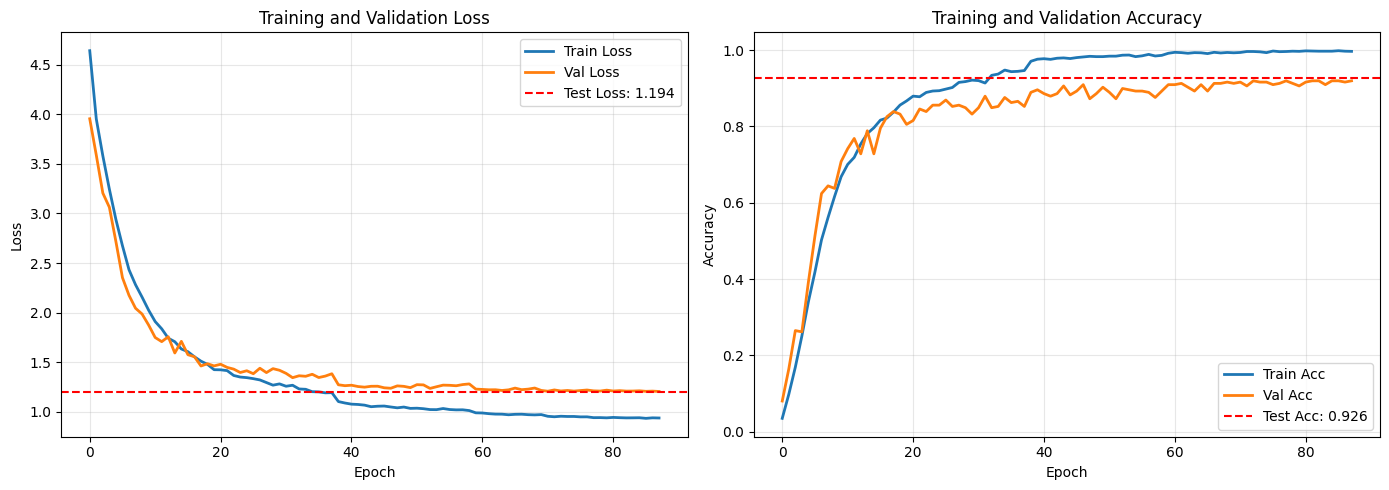

📊 Training plots saved to 'training_results.png'

✅ TRAINING COMPLETE!


In [5]:

# ============================================================
# APPLY TCN MODEL TO YOUR PROCESSED DATA (FIXED)
# ============================================================

import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ============================================================
# CONFIGURATION - ADJUST FOR YOUR DATA
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Get dimensions from your data
FEATURE_DIM = processed_data.shape[2]  # Should be 438
TARGET_FRAMES = processed_data.shape[1]  # Max frames from your data

print(f"📊 Data Information:")
print(f"   Feature dimension: {FEATURE_DIM}")
print(f"   Target frames: {TARGET_FRAMES}")
print(f"   Total samples: {len(processed_data)}")

# ============================================================
# ENCODE LABELS AND CHECK CLASS DISTRIBUTION
# ============================================================

# Encode labels
le = LabelEncoder()
all_labels_encoded = le.fit_transform(processed_labels)
num_classes = len(le.classes_)

print(f"\n🏷️ Label encoding complete: {num_classes} classes")

# Check class distribution
label_counts = Counter(processed_labels)
print(f"\n📊 Class distribution:")
print(f"   Total classes: {num_classes}")
print(f"   Min samples per class: {min(label_counts.values())}")
print(f"   Max samples per class: {max(label_counts.values())}")
print(f"   Mean samples per class: {np.mean(list(label_counts.values())):.2f}")

# Find classes with very few samples
rare_classes = {label: count for label, count in label_counts.items() if count < 3}
if rare_classes:
    print(f"\n⚠️ Classes with <3 samples ({len(rare_classes)} classes):")
    for label, count in list(rare_classes.items())[:10]:
        print(f"   {label}: {count} sample(s)")

# ============================================================
# FILTER RARE CLASSES (OPTIONAL)
# ============================================================

# Option 1: Remove classes with very few samples
MIN_SAMPLES_PER_CLASS = 2  # Minimum samples required to keep a class

if min(label_counts.values()) < MIN_SAMPLES_PER_CLASS:
    print(f"\n⚠️ Filtering classes with < {MIN_SAMPLES_PER_CLASS} samples...")
    
    # Keep only classes with enough samples
    keep_classes = [label for label, count in label_counts.items() if count >= MIN_SAMPLES_PER_CLASS]
    keep_mask = [label in keep_classes for label in processed_labels]
    
    processed_data_filtered = processed_data[keep_mask]
    processed_masks_filtered = processed_masks[keep_mask]
    processed_labels_filtered = processed_labels[keep_mask]
    
    # Re-encode labels
    le = LabelEncoder()
    all_labels_encoded = le.fit_transform(processed_labels_filtered)
    num_classes = len(le.classes_)
    
    print(f"   Removed {len(processed_labels) - len(processed_labels_filtered)} samples")
    print(f"   Removed {len(label_counts) - num_classes} rare classes")
    print(f"   Remaining classes: {num_classes}")
    print(f"   Remaining samples: {len(processed_labels_filtered)}")
    
    # Update data
    processed_data = processed_data_filtered
    processed_masks = processed_masks_filtered
    processed_labels = processed_labels_filtered
else:
    print(f"\n✅ All classes have at least {MIN_SAMPLES_PER_CLASS} samples")

# ============================================================
# CREATE STRATIFIED SPLIT (WITH FALLBACK)
# ============================================================

print(f"\n📊 Creating train/val/test splits...")

# First split: separate test set (20%)
try:
    X_train, X_temp, y_train, y_temp, m_train, m_temp = train_test_split(
        processed_data, all_labels_encoded, processed_masks,
        test_size=0.2, stratify=all_labels_encoded, random_state=42
    )
    
    # Second split: separate validation from remaining (25% of remaining = 20% of total)
    X_val, X_test, y_val, y_test, m_val, m_test = train_test_split(
        X_temp, y_temp, m_temp,
        test_size=0.5, stratify=y_temp, random_state=42
    )
    
    print(f"✅ Stratified split successful")
    
except ValueError as e:
    print(f"⚠️ Stratified split failed: {e}")
    print("   Falling back to non-stratified split...")
    
    # Fallback: non-stratified split
    X_train, X_temp, y_train, y_temp, m_train, m_temp = train_test_split(
        processed_data, all_labels_encoded, processed_masks,
        test_size=0.3, random_state=42
    )
    
    X_val, X_test, y_val, y_test, m_val, m_test = train_test_split(
        X_temp, y_temp, m_temp,
        test_size=0.5, random_state=42
    )
    
    print(f"✅ Non-stratified split completed")

print(f"\n📊 Split sizes:")
print(f"   Train: {len(X_train)} samples")
print(f"   Validation: {len(X_val)} samples")
print(f"   Test: {len(X_test)} samples")

# Check class distribution in splits
print(f"\n📊 Class distribution in splits:")
print(f"   Train classes: {len(np.unique(y_train))}")
print(f"   Val classes: {len(np.unique(y_val))}")
print(f"   Test classes: {len(np.unique(y_test))}")

# ============================================================
# DATASET CLASS
# ============================================================

class ASLDataset(Dataset):
    def __init__(self, data, masks, labels, augment=False):
        self.data = torch.from_numpy(data).float()
        self.masks = torch.from_numpy(masks).float()
        self.labels = torch.from_numpy(labels).long()
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.data[idx]
        m = self.masks[idx]
        y = self.labels[idx]
        
        # Simple augmentation for training (optional)
        if self.augment:
            # Add small noise
            if torch.rand(1) > 0.5:
                noise = torch.randn_like(x) * 0.01
                x = x + noise
            
            # Random scaling
            if torch.rand(1) > 0.5:
                scale = torch.rand(1) * 0.2 + 0.9
                x = x * scale
        
        # Transpose for Conv1d
        x = x.transpose(0, 1)
        
        return x, m, y

# ============================================================
# CREATE DATALOADERS
# ============================================================

BATCH_SIZE = min(8, len(X_train))  # Adjust based on your memory
NUM_WORKERS = 0

train_dataset = ASLDataset(X_train, m_train, y_train, augment=True)
val_dataset = ASLDataset(X_val, m_val, y_val, augment=False)
test_dataset = ASLDataset(X_test, m_test, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\n✅ DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# ============================================================
# TCN MODEL DEFINITION
# ============================================================

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__()
        padding = dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.Dropout(0.3),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.Dropout(0.3),
            nn.ReLU(inplace=True),
        )
        self.res = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        y = self.net(x)
        if y.size(2) != x.size(2):
            y = y[..., :x.size(2)]
        return y + self.res(x)

class TCN(nn.Module):
    def __init__(self, input_dim, num_classes, num_channels=64, num_layers=3):
        super().__init__()
        # Adjust number of layers based on dataset size
        actual_layers = min(num_layers, len(X_train) // 10)  # Don't use too many layers for small dataset
        channels = [num_channels] * max(1, actual_layers)
        
        layers = []
        for i, c in enumerate(channels):
            in_dim = input_dim if i == 0 else channels[i-1]
            layers.append(TemporalBlock(in_dim, c, dilation=2**i))
        
        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(channels[-1], num_classes)
        self.dropout = nn.Dropout(0.4)
        
    def masked_pool(self, x, mask):
        """Masked global average pooling"""
        mask = mask.unsqueeze(1)  # (batch, 1, time)
        masked_x = x * mask
        summed = masked_x.sum(dim=2)
        valid_counts = mask.sum(dim=2).clamp(min=1)
        return summed / valid_counts
    
    def forward(self, x, mask):
        x = self.tcn(x)
        x = self.masked_pool(x, mask)
        x = self.dropout(x)
        return self.fc(x)

# Adjust model size based on dataset
if len(X_train) < 50:
    num_channels = 32
    num_layers = 2
    print(f"\n📐 Small dataset detected. Using smaller model: {num_layers} layers, {num_channels} channels")
elif len(X_train) < 200:
    num_channels = 64
    num_layers = 3
    print(f"\n📐 Medium dataset detected. Using medium model: {num_layers} layers, {num_channels} channels")
else:
    num_channels = 128
    num_layers = 4
    print(f"\n📐 Large dataset detected. Using larger model: {num_layers} layers, {num_channels} channels")

# Initialize model
model = TCN(
    input_dim=FEATURE_DIM, 
    num_classes=num_classes,
    num_channels=num_channels,
    num_layers=num_layers
).to(DEVICE)

# Calculate model size
total_params = sum(p.numel() for p in model.parameters())
params_per_sample = total_params / len(X_train)

print(f"\n📐 MODEL ARCHITECTURE:")
print(f"   Input: {FEATURE_DIM} x {TARGET_FRAMES}")
print(f"   Architecture: TCN with {num_layers} layers, {num_channels} channels")
print(f"   Total parameters: {total_params:,}")
print(f"   Parameters per sample: {params_per_sample:.1f}")

if params_per_sample > 500:
    print(f"   ⚠️ WARNING: Model may overfit! Consider reducing channels or layers.")
elif params_per_sample < 50:
    print(f"   ✅ Model size appropriate for dataset")
else:
    print(f"   ⚠️ Model size acceptable")

# ============================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================

# Compute class weights for imbalance (handle case with single class)
if num_classes > 1:
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    print(f"\n⚖️ Class weights computed for {num_classes} classes")
else:
    class_weights = None
    print(f"\n⚠️ Only one class found. Using standard cross-entropy.")

class SmoothCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
        
    def forward(self, logits, targets):
        n_classes = logits.size(1)
        if n_classes == 1:
            # Binary case
            return nn.functional.binary_cross_entropy_with_logits(logits.squeeze(), targets.float())
        
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        
        log_probs = torch.log_softmax(logits, dim=1)
        
        if self.weight is not None:
            weight = self.weight[targets]
            loss = -(true_dist * log_probs).sum(dim=1) * weight
        else:
            loss = -(true_dist * log_probs).sum(dim=1)
            
        return loss.mean()

# Training configuration
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 100
PATIENCE = 15
GRAD_CLIP = 1.0
LABEL_SMOOTH = 0.1

criterion = SmoothCrossEntropy(smoothing=LABEL_SMOOTH, weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ============================================================
# TRAINING FUNCTIONS
# ============================================================

def train_one_epoch(loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, m, y in loader:
        x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(x, m)
        loss = criterion(outputs, y)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        
        total_loss += loss.item() * y.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y).sum().item()
        total += y.size(0)
    
    return total_loss / total, correct / total

def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, m, y in loader:
            x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
            outputs = model(x, m)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * y.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(y).sum().item()
            total += y.size(0)
    
    return total_loss / total, correct / total

# ============================================================
# TRAINING LOOP
# ============================================================

print("\n" + "="*60)
print("🚀 STARTING TRAINING")
print("="*60)
print(f"   Device: {DEVICE}")
print(f"   Training samples: {len(X_train)}")
print(f"   Validation samples: {len(X_val)}")
print(f"   Test samples: {len(X_test)}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Learning rate: {LR}")
print(f"   Epochs: {EPOCHS}")
print("="*60)

best_val_acc = 0
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(train_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc = evaluate(val_loader)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Update scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Print progress
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"LR: {current_lr:.2e} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'train_loss': train_loss,
        }, 'best_tcn_model.pth')
        print(f"  ✅ Best model saved! (Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break

# ============================================================
# FINAL EVALUATION
# ============================================================

print("\n" + "="*60)
print("📊 FINAL EVALUATION")
print("="*60)

# Load best model
checkpoint = torch.load('best_tcn_model.pth', map_location=torch.device(DEVICE))
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"   Validation Accuracy: {checkpoint['val_acc']:.4f}")

# Test evaluation
test_loss, test_acc = evaluate(test_loader)
print(f"\n🎯 TEST SET RESULTS:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# ============================================================
# SAVE RESULTS
# ============================================================

# Save label encoder
np.save('label_encoder.npy', le.classes_)

# Save training history
history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'test_loss': test_loss,
    'num_classes': num_classes,
    'target_frames': TARGET_FRAMES,
    'feature_dim': FEATURE_DIM,
    'model_params': total_params,
}

with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print(f"\n💾 Saved files:")
print(f"   Model: best_tcn_model.pth")
print(f"   Label encoder: label_encoder.npy")
print(f"   Training history: training_history.pkl")

# ============================================================
# PLOT RESULTS
# ============================================================

try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(train_losses, label='Train Loss', linewidth=2)
    axes[0].plot(val_losses, label='Val Loss', linewidth=2)
    axes[0].axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.3f}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(train_accs, label='Train Acc', linewidth=2)
    axes[1].plot(val_accs, label='Val Acc', linewidth=2)
    axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.3f}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_results.png', dpi=150)
    plt.show()
    print("📊 Training plots saved to 'training_results.png'")
    
except Exception as e:
    print(f"⚠️ Could not plot: {e}")

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)